### Importing libraries

In [136]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from xgboost import XGBRegressor, XGBRFRegressor,XGBRFClassifier,XGBRFClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay

In [137]:
# Reading the file
path_to_file = "../Data/cleaned_credit_risk.csv"
df = pd.read_csv(path_to_file)
df.head(5)

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,5.0,2,1000,11.14,0,0.10,0,2
1,25,9600,1.0,3,5500,12.87,1,0.57,0,3
2,23,65500,4.0,3,35000,15.23,1,0.53,0,2
3,24,54400,8.0,3,35000,14.27,1,0.55,1,4
4,21,9900,2.0,1,2500,7.14,1,0.25,0,2


In [138]:
df.isna().sum()

person_age                       0
person_income                    0
person_emp_length                0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3039
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [139]:
df =df.drop("loan_int_rate", axis=1)

In [140]:
df.isna().sum()

person_age                    0
person_income                 0
person_emp_length             0
loan_grade                    0
loan_amnt                     0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [141]:
df = df.drop_duplicates()

###  I would use four different ML models to predict the best age for granting a loan, where 1 represents the best outcome and 0 the worst. 

<function matplotlib.pyplot.show(close=None, block=None)>

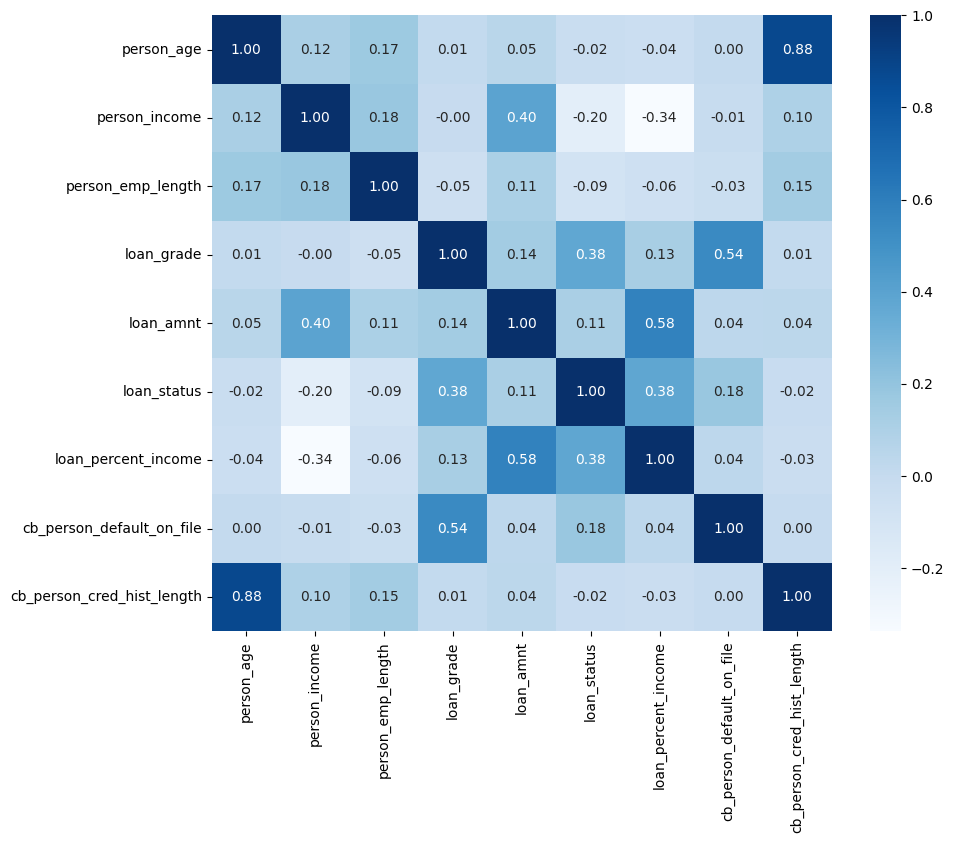

In [142]:
## Doing correlation matrix
plt.figure(figsize=(10,8))
cor_matrix = df.corr(numeric_only=True)
sns.heatmap(cor_matrix, cmap="Blues", annot=True, fmt=".2f")
plt.show

In [143]:
x = df.drop([
    "loan_status",
    "loan_grade",
    "cb_person_default_on_file"  # usein myös leakage
], axis=1)
y = df["loan_status"]


In [144]:
y

0        0
1        1
2        1
3        1
4        1
        ..
31617    0
31618    0
31619    1
31620    0
31621    0
Name: loan_status, Length: 30873, dtype: int64

In [145]:
x_train, x_temp, y_train, y_temp = train_test_split(x,y, test_size=0.3, random_state=42)

In [146]:
x_val, x_test, y_val, y_test = train_test_split(x_temp,y_temp, test_size = 0.5, random_state=42)


In [147]:
model_logistic = LogisticRegression().fit(x_train,y_train)
model_xg = XGBRFClassifier().fit(x_train,y_train)
model_rand = RandomForestClassifier().fit(x_train,y_train)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [148]:
y_val_log_model_predict =model_logistic.predict(x_val)
y_val_model_xg_predict = model_xg.predict(x_val)  
y_val_model_rand_predict= model_rand.predict(x_val)
 

In [149]:
print("Result for accuracy train data")
print(" ")
print("Logistic regression", accuracy_score(y_val, y_val_log_model_predict))
print("RFC", accuracy_score(y_val, y_val_model_rand_predict))
print("XGBRFClassifier", accuracy_score(y_val, y_val_model_xg_predict))

Result for accuracy train data
 
Logistic regression 0.796804145972792
RFC 0.8466853811271864
XGBRFClassifier 0.8410710429712805


In [150]:
print("Result for confusion matrix train data")
print(" ")
print("Logistic regression", confusion_matrix(y_val, y_val_log_model_predict))
print("RFC", confusion_matrix(y_val, y_val_model_rand_predict))
print("XGBRFClassifier", confusion_matrix(y_val, y_val_model_xg_predict))

Result for confusion matrix train data
 
Logistic regression [[3578   55]
 [ 886  112]]
RFC [[3471  162]
 [ 548  450]]
XGBRFClassifier [[3489  144]
 [ 592  406]]


## Lets do for the test data

In [151]:
y_test_log_model_predict =model_logistic.predict(x_test)
y_test_model_xg_predict = model_xg.predict(x_test)  
y_test_model_rand_predict= model_rand.predict(x_test)
 

In [152]:
print("Result for accuracy train data")
print(" ")
print("Logistic regression", accuracy_score(y_test, y_test_log_model_predict))
print("RFC", accuracy_score(y_test, y_test_model_xg_predict))
print("XGBRFClassifier", accuracy_score(y_test, y_test_model_rand_predict))

Result for accuracy train data
 
Logistic regression 0.8045778449578924
RFC 0.8471172532930252
XGBRFClassifier 0.8412869790541999


In [153]:
df.duplicated().sum()

0